In [1]:
import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from pathlib import Path
import plotly.express as px
import igraph as ig
from pathlib import Path
import joblib
import pickle, gzip
import ast
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from collections import Counter
from collections import defaultdict
import sys


import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Obtained from 01_publication_classification
ROOT_DISAMBIGUATED_CLASSIFICATION_DIR = '../data/open_alex_matches/'
matches_df = pd.read_csv(ROOT_DISAMBIGUATED_CLASSIFICATION_DIR + '/matches.csv.gz', engine = 'python', compression="gzip")

In [3]:
# version 2025aug Oct 29, 2025. zenedo: 10.5281/zenodo.17442025
ROOT_CLASSIFICATION_DIR = '../data/classification_openalex_2025/'
micro_cluster_path = ROOT_CLASSIFICATION_DIR + 'micro_cluster.tsv'
micro_cluster_df = pd.read_csv(micro_cluster_path, sep =  '\\t', engine='python')

In [4]:
ROOT_VECTOR_EMBEDDINGS_DIR = Path("../data/vector/")

In [11]:
agg_test_df = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "agg_test_df.csv.gz", engine='python', compression='gzip')

# convert software_list to a list
agg_test_df['software_list'] = agg_test_df['software_list'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [6]:
agg_test_df

,doi,software_list
0,10.1001/jamacardio.2021.0961,"[CVI42, Circle Cardiovascular Imaging, SPSS, R]"
1,10.1001/jamadermatol.2020.0796,"[SOLO, Engauge Digitizer, gemtc, R]"
2,10.1001/jamainternmed.2019.2322,"[Eurotransplant, survRM2, R, Stata]"
3,10.1001/jamainternmed.2020.0146,"[Stata, Excel]"
4,10.1001/jamanetworkopen.2018.0789,"[SPSS, OLIN]"
...,...,...
187164,10.7717/peerj.9970,"[QIIME, UPARSE, UCHIME, Classifier, R, UPGMA]"
187165,10.7717/peerj.9971,"[Spectrum, Proteome Discoverer, BLAST, SigmaPlot]"
187166,10.7717/peerj.998,"[R, nlme]"
187167,10.7717/peerj.9991,"[Lasergene, DNA Star, BLAST, MEGA, BioEdit, St..."


In [5]:
community_summary_df = pd.read_csv("../data/leiden_micro/community_summary_micro.csv.gz", compression="gzip")

# The columns have to be converted back into dictionaries when it has been read out. 
dict_columns = ['software_freq', 'doi_freq', 'macro_cluster_freq', 
                'meso_cluster_freq', 'micro_cluster_freq', 'main_field_freq']

for col in dict_columns:
    community_summary_df[col] = community_summary_df[col].apply(ast.literal_eval)

In [8]:
community_summary_df

,community,community_size,doi_count,software_freq,doi_freq,macro_cluster_freq,meso_cluster_freq,micro_cluster_freq,main_field_freq,micro_cluster_id,community_index,modularity
0,0,39,69,"{'ZAF': 2, 'CorelDRAW X3': 2, 'Microsoft Power...","{'10.1038/s41598-018-19342-w': 2, '10.1038/s41...",{7: 69},{10: 69},{1: 69},{'Life and earth sciences': 69},1,0,0.683722
1,1,32,42,"{'Linux Kernel': 1, 'Generic Mapping Tools': 4...","{'10.3390/s140100672': 2, '10.1038/s41598-017-...",{7: 42},{10: 42},{1: 42},{'Life and earth sciences': 42},1,1,0.683722
2,2,24,16,"{'graphics': 1, 'RAMA': 1, 'AVIZO® Fire': 1, '...","{'10.1038/s41598-018-26644-6': 6, '10.1007/s00...",{7: 16},{10: 16},{1: 16},{'Life and earth sciences': 16},1,2,0.683722
3,3,24,32,"{'WIRE': 1, 'MorphoLibJ': 1, 'OPUS': 1, 'suite...","{'10.1038/s41598-020-65226-3': 3, '10.1038/s41...",{7: 32},{10: 32},{1: 32},{'Life and earth sciences': 32},1,3,0.683722
4,4,24,12,"{'PHREEQC': 3, 'QIIME': 2, 'FLASH': 1, 'Keras'...","{'10.1007/s00445-015-0945-8': 2, '10.1126/scia...",{7: 12},{10: 12},{1: 12},{'Life and earth sciences': 12},1,4,0.683722
...,...,...,...,...,...,...,...,...,...,...,...,...
44299,44299,2,1,"{'Excel': 1, 'SPSS': 1}",{'10.11604/pamj.2020.37.302.20521': 2},{5: 1},{33: 1},{4514: 1},{'Mathematics and computer science': 1},4514,0,0.000000
44300,44300,17,2,"{'Automatic Annotation Server (KAAS)': 1, 'KAA...","{'10.1186/1471-2164-15-1126': 14, '10.1038/s41...",{4: 2},{83: 2},{4521: 2},"{'Life and earth sciences': 2, 'Biomedical and...",4521,0,0.520277
44301,44301,11,1,"{'Search Tool for': 1, 'Trans-Proteomic Pipeli...",{'10.1186/s12870-018-1304-7': 11},{4: 1},{83: 1},{4521: 1},"{'Life and earth sciences': 1, 'Biomedical and...",4521,1,0.520277
44302,44302,10,5,"{'SPSS': 3, 'JMP Pro': 1, 'Spss': 1, 'MultiExp...","{'10.1038/s41598-018-35605-y': 1, '10.1038/sre...",{4: 5},{83: 5},{4521: 5},"{'Life and earth sciences': 5, 'Biomedical and...",4521,2,0.520277


In [6]:
train_embeddings = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "train_embeddings.csv.gz", engine='python', compression='gzip')
test_embeddings = pd.read_csv(ROOT_VECTOR_EMBEDDINGS_DIR / "test_embeddings.csv.gz", engine='python', compression='gzip')

def parse_embedding(val):
    if isinstance(val, np.ndarray):
        return val
    return np.fromstring(val.strip("[]"), sep=" ")

train_embeddings['abs_embedding'] = train_embeddings['abs_embedding'].apply(parse_embedding)
test_embeddings['abs_embedding'] = test_embeddings['abs_embedding'].apply(parse_embedding)


In [7]:
test_embeddings = test_embeddings.merge(
    matches_df[['doi', 'macro_cluster_id', 'meso_cluster_id', 'micro_cluster_id']],
    on='doi',
    how='left'
)
test_embeddings

,doi,abs_embedding,macro_cluster_id,meso_cluster_id,micro_cluster_id
0,10.1099/mgen.0.000161,"[0.0281690732, -0.0777003244, -0.0447983518, 0...",4,174,486
1,10.1016/j.celrep.2018.08.010,"[-0.0212364309, -0.063418515, -0.0717834383, 0...",3,6,581
2,10.3389/fnhum.2015.00077,"[0.0455544591, 0.0286879353, -0.0550108775, 0....",3,6,427
3,10.3390/ijms19103049,"[0.0443590581, -0.0646726415, -0.0466362573, -...",1,153,123
4,10.1007/s00266-018-1298-4,"[0.00428551855, 0.0458282083, -0.0523110405, 0...",15,691,1322
...,...,...,...,...,...
187344,10.3897/zookeys.463.8397,"[-0.0100124562, -0.0482294597, -0.0320331566, ...",4,11,895
187345,10.3390/ijms20112636,"[-0.0171696562, -0.0290033221, -0.0917966068, ...",1,224,176
187346,10.1371/journal.pone.0048687,"[0.0494167469, -0.0891364515, 0.0578807518, 0....",1,266,261
187347,10.1016/j.bbr.2016.03.015,"[0.011814977, -0.0169856064, -0.0285508055, 0....",1,132,1685


In [8]:
train_embeddings = train_embeddings.merge(
    matches_df[['doi', 'macro_cluster_id', 'meso_cluster_id', 'micro_cluster_id']],
    on='doi',
    how='left'
)

def distinction_set(train_embeddings, test_embeddings) -> tuple[set, set]:
    micro_in_training = set(train_embeddings['micro_cluster_id'])
    micro_in_test     = set(test_embeddings['micro_cluster_id'])

    exclusive_in_training = micro_in_training - micro_in_test  # only in train
    exclusive_in_test     = micro_in_test - micro_in_training  # only in test

    return exclusive_in_training, exclusive_in_test

exclusive_train, exclusive_test = distinction_set(train_embeddings, test_embeddings)
print(f"Micro clusters only in train : {len(exclusive_train)}")
print(f"Micro clusters only in test  : {len(exclusive_test)}")
print(f"Shared                       : {len(set(train_embeddings['micro_cluster_id']) & set(test_embeddings['micro_cluster_id']))}")

Micro clusters only in train : 533
Micro clusters only in test  : 87
Shared                       : 2772


In [11]:
print(len(train_embeddings))
print(len(test_embeddings))

749549
187349


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path


ROOT_VECTOR_MICRO_DIR = Path("../data/vector_micro/")

def get_micro_cluster_centres(train_embeddings: pd.DataFrame) -> dict:
    """
    Compute a centroid vector per micro_cluster_id using training embeddings.
    Returns dict: {micro_cluster_id: np.ndarray}
    """
    micro_cluster_means = {}

    for micro_id, group in train_embeddings.groupby("micro_cluster_id"):
        matrix = np.vstack(group["abs_embedding"].values)
        micro_cluster_means[micro_id] = matrix.mean(axis=0)

    return micro_cluster_means

def assign_predicted_micro_cluster(embeddings: pd.DataFrame, micro_cluster_means: dict) -> pd.DataFrame:
    """
    For each document in embeddings, assign the micro_cluster_id whose
    centroid is most similar (cosine) to the document's abstract embedding.
    """
    cluster_labels  = list(micro_cluster_means.keys())
    cluster_matrix  = np.vstack(list(micro_cluster_means.values()))  
    doc_matrix      = np.vstack(embeddings["abs_embedding"].values) 

    sims        = cosine_similarity(doc_matrix, cluster_matrix)       
    closest_idx = np.argmax(sims, axis=1)

    embeddings = embeddings.copy()
    embeddings["predicted_micro_cluster_id"] = [cluster_labels[i] for i in closest_idx]
    embeddings["prediction_confidence"]       = sims.max(axis=1) 
    return embeddings

def get_software_community_mapping_from_df(micro_cluster_id: int, community_summary_df: pd.DataFrame) -> dict:
    """
    Returns {software_name: community_index} for a given micro cluster,
    built from community_summary_df['software_freq'].
    """
    cluster_communities = community_summary_df[
        community_summary_df['micro_cluster_id'] == micro_cluster_id
    ]

    sw_to_community = {}
    for _, row in cluster_communities.iterrows():
        for software in row['software_freq'].keys():
            sw_to_community[software] = row['community_index']

    return sw_to_community


def get_community_software_from_df(micro_cluster_id: int, community_index: int, community_summary_df: pd.DataFrame) -> list:
    """
    Returns all software in a specific community of a micro cluster.
    """
    match = community_summary_df[
        (community_summary_df['micro_cluster_id'] == micro_cluster_id) &
        (community_summary_df['community_index'] == community_index)
    ]

    if match.empty:
        return []

    return list(match.iloc[0]['software_freq'].keys())


class MicroClusterEvaluator:
    def __init__(
        self,
        community_summary_df: pd.DataFrame,
        save_dir: Path | None = None
    ):
        self.community_summary_df = community_summary_df
        self.save_dir             = Path(save_dir) if save_dir else None
        self.results_df           = None

        # precompute {micro_cluster_id: {software: community_index}} to avoid repeated df lookups
        self._sw_to_community_cache = {
            micro_id: get_software_community_mapping_from_df(micro_id, community_summary_df)
            for micro_id in community_summary_df['micro_cluster_id'].unique()
        }

    def evaluate(self, test_df: pd.DataFrame, agg_test_df: pd.DataFrame) -> pd.DataFrame:
        df = test_df.merge(agg_test_df[['doi', 'software_list']], on='doi', how='left')
        df['correct'] = df['micro_cluster_id'] == df['predicted_micro_cluster_id']

        rows = []
        for _, row in df.iterrows():
            predicted_cluster_id = row['predicted_micro_cluster_id']
            paper_software       = set(row['software_list']) if isinstance(row['software_list'], list) else set()

            sw_to_community    = self._sw_to_community_cache.get(predicted_cluster_id, {})
            matched_software   = paper_software & set(sw_to_community.keys())
            unmatched_software = paper_software - set(sw_to_community.keys())

            matched_sw_communities = {sw: sw_to_community[sw] for sw in matched_software}

            dominant_community = None
            if matched_sw_communities:
                dominant_community = Counter(matched_sw_communities.values()).most_common(1)[0][0]

            dominant_community_software = []
            if dominant_community is not None:
                dominant_community_software = get_community_software_from_df(
                    predicted_cluster_id, dominant_community, self.community_summary_df
                )

            rows.append({
                'doi':                         row['doi'],
                'micro_cluster_id':            row['micro_cluster_id'],
                'predicted_micro_cluster_id':  predicted_cluster_id,
                'prediction_confidence':       row.get('prediction_confidence', None),
                'correct':                     row['correct'],
                'paper_software':              list(paper_software),
                'matched_software':            list(matched_software),
                'unmatched_software':          list(unmatched_software),
                'matched_sw_communities':      matched_sw_communities,
                'dominant_community':          dominant_community,
                'dominant_community_software': dominant_community_software,
                'software_match_count':        len(matched_software),
                'software_match_ratio':        len(matched_software) / len(paper_software) if paper_software else 0.0,
            })

        self.results_df = pd.DataFrame(rows)

        if self.save_dir:
            self.results_df.to_csv(self.save_dir / "micro_cluster_evaluation_results.csv.gz", index=False, compression="gzip")

        return self.results_df

    def compute_metrics(self) -> pd.DataFrame:
        if self.results_df is None:
            raise Exception("results have not yet been generated. Make sure to run 'evaluate' first.")

        df       = self.results_df
        correct  = df["correct"].sum()
        total    = len(df)
        accuracy = correct / total if total > 0 else 0.0

        print(f"Accuracy: {accuracy:.4f}  ({correct}/{total})")

        clusters = set(df["micro_cluster_id"]) | set(df["predicted_micro_cluster_id"])
        rows = []
        for cluster in clusters:
            tp = len(df[(df["predicted_micro_cluster_id"] == cluster) & (df["micro_cluster_id"] == cluster)])
            fp = len(df[(df["predicted_micro_cluster_id"] == cluster) & (df["micro_cluster_id"] != cluster)])
            fn = len(df[(df["predicted_micro_cluster_id"] != cluster) & (df["micro_cluster_id"] == cluster)])

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            rows.append({
                "micro_cluster_id": cluster,
                "tp": tp, "fp": fp, "fn": fn,
                "precision": precision, "recall": recall, "f1": f1,
                "support":   tp + fn,
            })

        metrics_df = pd.DataFrame(rows).sort_values("support", ascending=False)

        total_tp          = metrics_df["tp"].sum()
        total_fp          = metrics_df["fp"].sum()
        total_fn          = metrics_df["fn"].sum()
        total_predictions = total_tp + total_fp

        micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        micro_recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
        micro_f1        = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0

        print(f"\n Overall (micro-averaged from raw counts)")
        print(f"TP: {total_tp}  FP: {total_fp}  FN: {total_fn}")
        print(f"  TP proportion : {total_tp / total_predictions:.4f}")
        print(f"  FP proportion : {total_fp / total_predictions:.4f}")
        print(f"  FN proportion : {total_fn / total_predictions:.4f}")
        print(f"Precision : {micro_precision:.4f}")
        print(f"Recall    : {micro_recall:.4f}")
        print(f"F1        : {micro_f1:.4f}")

        if self.save_dir:
            metrics_df.to_csv(self.save_dir / "micro_cluster_metrics.csv.gz", index=False, compression="gzip")
            pd.DataFrame([{
                "total_tp": total_tp, "total_fp": total_fp, "total_fn": total_fn,
                "tp_proportion": total_tp / total_predictions,
                "fp_proportion": total_fp / total_predictions,
                "fn_proportion": total_fn / total_predictions,
                "precision": micro_precision, "recall": micro_recall, "f1": micro_f1,
                "accuracy": accuracy,
            }]).to_csv(self.save_dir / "micro_cluster_overall_metrics.csv.gz", index=False, compression="gzip")

        return metrics_df

# step 1. compute micro cluster centroids from training set
micro_cluster_means = get_micro_cluster_centres(train_embeddings)

# step 2. appoint each document to the nearest micro cluster centroid
test_embeddings     = assign_predicted_micro_cluster(test_embeddings, micro_cluster_means)

# step 3. prep the evalutor for indicating whether the predicted community was a best fit
evaluator  = MicroClusterEvaluator(
    community_summary_df=community_summary_df,
    save_dir=ROOT_VECTOR_MICRO_DIR,
)

results_df = evaluator.evaluate(test_embeddings, agg_test_df)
metrics_df = evaluator.compute_metrics()

Accuracy: 0.5279  (98901/187349)

--- Overall (micro-averaged from raw counts) ---
TP: 98901  FP: 88448  FN: 88448
  TP proportion : 0.5279
  FP proportion : 0.4721
  FN proportion : 0.4721
Precision : 0.5279
Recall    : 0.5279
F1        : 0.5279


In [9]:
def all_doi(community_summary_df):
    """
    Return the set of all unique DOI acros all communities
    """
    dois_set = set()
    for _, row in community_summary_df.iterrows():
        dois_set.update(row['doi_freq'].keys())
    return dois_set

dois_set = all_doi(community_summary_df)

In [18]:
print(len(dois_set))

748672


In [19]:
train_embeddings.head()

,doi,abs_embedding
0,10.1186/s12889-015-1852-9,"[-0.032375738, -0.0822128206, -0.0396279395, 0..."
1,10.1039/c7mt00324b,"[-0.0210759155, -0.0210289992, -0.0655881912, ..."
2,10.1016/j.funbio.2016.01.017,"[0.111265011, -0.0722485781, 0.044926811, 0.01..."
3,10.1002/ece3.5902,"[0.00834561605, 0.0125104384, -0.0703234598, 0..."
4,10.1186/s13104-021-05644-2,"[0.05581705, -0.04640558, -0.02643637, 0.04948..."


In [25]:
train_embeddings

,doi,abs_embedding
0,10.1186/s12889-015-1852-9,"[-0.032375738, -0.0822128206, -0.0396279395, 0..."
1,10.1039/c7mt00324b,"[-0.0210759155, -0.0210289992, -0.0655881912, ..."
2,10.1016/j.funbio.2016.01.017,"[0.111265011, -0.0722485781, 0.044926811, 0.01..."
3,10.1002/ece3.5902,"[0.00834561605, 0.0125104384, -0.0703234598, 0..."
4,10.1186/s13104-021-05644-2,"[0.05581705, -0.04640558, -0.02643637, 0.04948..."
...,...,...
749511,10.3390/cancers13010140,"[-0.0303858649, -0.072600238, -0.0558905415, 0..."
749512,10.3389/fnagi.2020.00048,"[-0.0363373645, 0.0340905227, -0.0463943332, 0..."
749513,10.3390/ijms18050981,"[-0.03996812, -0.00281119, -0.01516791, 0.0605..."
749514,10.3390/molecules23092185,"[0.0205164272, -0.0872388706, 0.00738654193, 0..."


In [10]:
from sklearn.metrics import silhouette_score

occurence_subset = train_embeddings[train_embeddings['doi'].isin(dois_set)]

# convert embeddings to matrix
embeddings =  np.vstack(occurence_subset['abs_embedding'].values) 
labels = occurence_subset['micro_cluster_id'].values

score = silhouette_score(X=embeddings, labels=labels, metric="cosine")
print(f"Silhouette_score_cosine: {score:.4f}")
silhoette_score_path = Path("../data/vector_micro/silhoette_micro.txt")
lines = [f"Silhouette_score_cosine: {score:.4f}"]
silhoette_score_path.write_text("\n".join(lines), encoding="utf-8")

Silhouette_score_cosine: -0.0803


32

In [ ]:
papers_with_exclusive_micro_cluster = results_df[results_df['micro_cluster_id'].isin(exclusive_test)]
print(len(papers_with_exclusive_micro_cluster))
len(papers_with_exclusive_micro_cluster[papers_with_exclusive_micro_cluster['correct'] == True])


101


,doi,micro_cluster_id,predicted_micro_cluster_id,prediction_confidence,correct,paper_software,matched_software,unmatched_software,matched_sw_communities,dominant_community,dominant_community_software,software_match_count,software_match_ratio
492,10.1371/journal.pone.0157312,3896,391,0.777616,False,"['SPSS', 'StatsDirect']",['SPSS'],['StatsDirect'],{'SPSS': 3},3.0,"['SURE', 'AMOS', 'Visual Basic for Application...",1,0.500000
3024,10.5195/jmla.2019.663,2884,1744,0.776633,False,"['Qualtrics', 'Zotero', 'Solstice']",['Qualtrics'],"['Zotero', 'Solstice']",{'Qualtrics': 5},5.0,"['VOSviewer', 'Ensembl', 'Microsoft Teams', 'A...",1,0.333333
12158,10.1155/2021/4674140,3693,1439,0.760868,False,"['MapReduce', 'Windows10', 'MATLAB']","['MapReduce', 'MATLAB']",['Windows10'],"{'MapReduce': 2, 'MATLAB': 5}",2.0,"['Weka', 'SURF', 'MPEG', 'FLANN', 'MapReduce',...",2,0.666667
14798,10.3390/s21030792,3935,1005,0.700667,False,"['Verilog', 'Prime', 'Edition', 'Lite', 'Power...",[],"['Verilog', 'Prime', 'Edition', 'Lite', 'Power...",{},NaN,[],0,0.000000
15055,10.3390/ma13215032,2250,2197,0.694965,False,"['OpenCV', 'Mathcad', 'QuickTime']",[],"['OpenCV', 'Mathcad', 'QuickTime']",{},NaN,[],0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
171937,10.3389/fpubh.2020.550051,2245,168,0.869871,False,"['SPSS', 'Questionnaire Star']","['SPSS', 'Questionnaire Star']",[],"{'SPSS': 0, 'Questionnaire Star': 0}",0.0,"['MCA', 'Harman', 'SPSS Statistical Package', ...",2,1.000000
172194,10.1186/s12909-019-1876-4,3270,350,0.779631,False,"['Snapchat', 'Denso Wave', 'Excel']",['Excel'],"['Snapchat', 'Denso Wave']",{'Excel': 0},0.0,"['MUMC', 'Skype', 'INPS Vision', 'System Onlin...",1,0.333333
185863,10.3390/ma13051056,2699,723,0.655446,False,"['COMSOL', 'MATLAB']",['MATLAB'],['COMSOL'],{'MATLAB': 1},1.0,"['AZtecHKL', 'MATLAB', 'Adobe Photoshop', 'Aba...",1,0.500000
186017,10.1007/s41244-021-00214-2,2373,3910,0.764583,False,"['Metapher', 'Phoenix']",[],"['Metapher', 'Phoenix']",{},NaN,[],0,0.000000


In [6]:
evaluation = pd.read_csv('../data/vector_micro/micro_cluster_evaluation_results.csv.gz', compression="gzip")

In [10]:
set(evaluation[evaluation['correct'] == True]['micro_cluster_id'].values)

{np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.int64(68),
 np.int64(69),
 np.int64(70),
 np.int64(71),
 np.int64(72),
 np.int64(73),
 np.

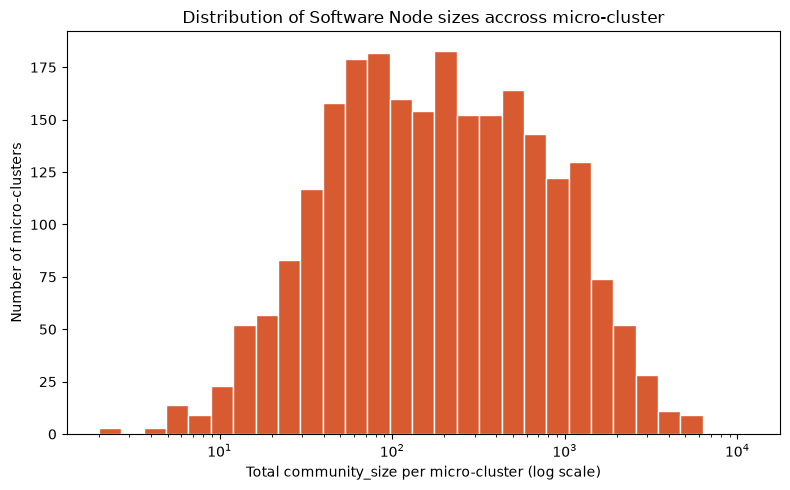

n               = 2415
mean            = 449.4
median          = 180.0
std             = 707.4
min             = 2
max             = 11451
quantile 1      = 61.0
Quantile 3      = 550.0
IQR             = 489.0
upper whisker   = 1283.5
lower whisker   = 2.0
n outliers      = 219 (9.1%)


C:\Users\Kayle\AppData\Local\Temp\ipykernel_36544\2314999911.py:55: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(micro_cluster_sizes.values, vert=True)


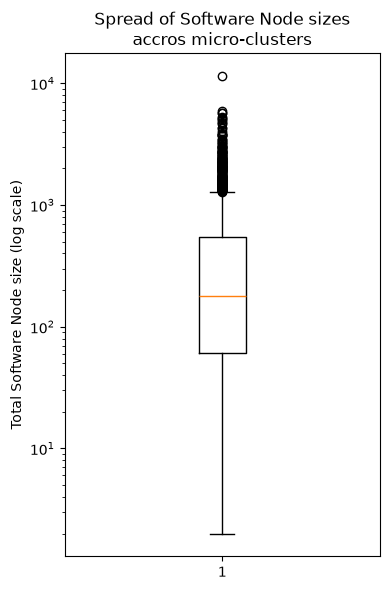

In [ ]:
ROOT_FIGURES_DIR = Path('../images_micro_micro/')

def plot_micro_cluster_community_size(
    community_summary_df,
    evaluation,
    save_enabled: bool = False,
):
    """
    COPY PASTAAAADDDD (LOVE ME A PASTA) FROM 10_MICRO_FOCUSED_VISUALIZATIONS.IPYNB
    Distribution of Software vertices of micro clusters of the reference set that were correctly predicted
    """
    micro_clusters_with_correct_prediction = set(evaluation[evaluation['correct'] == True]['micro_cluster_id'].values)

    micro_cluster_sizes = (
        community_summary_df[community_summary_df['micro_cluster_id'].isin(micro_clusters_with_correct_prediction)]
        .groupby('micro_cluster_id')['community_size']
        .sum()
        .sort_values(ascending=False)
    )


    fig, ax = plt.subplots(figsize=(8, 5))
    bins = np.logspace(np.log10(micro_cluster_sizes.min()),
                        np.log10(micro_cluster_sizes.max()), 30)
    ax.hist(micro_cluster_sizes, bins=bins, color='#D85A30', edgecolor='white')
    ax.set_xscale('log')
    ax.set_xlabel('Total community_size per micro-cluster (log scale)')
    ax.set_ylabel('Number of micro-clusters')
    ax.set_title('Distribution of Software Node sizes accross micro-cluster')
    plt.tight_layout()
    plt.savefig(ROOT_FIGURES_DIR / 'Distribution_of_Software_Node_sizes_accross_micro_cluster_(succes_only)')
    plt.show()

    desc = micro_cluster_sizes.describe()
    q1, q3 = micro_cluster_sizes.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_whisker = q3 + 1.5 * iqr
    lower_whisker = max(q1 - 1.5 * iqr, micro_cluster_sizes.min())
    outliers = micro_cluster_sizes[micro_cluster_sizes > upper_whisker]

    print(f"n               = {len(micro_cluster_sizes)}")
    print(f"mean            = {desc['mean']:.1f}")
    print(f"median          = {desc['50%']:.1f}")
    print(f"std             = {desc['std']:.1f}")
    print(f"min             = {desc['min']:.0f}")
    print(f"max             = {desc['max']:.0f}")
    print(f"quantile 1      = {q1:.1f}")
    print(f"Quantile 3      = {q3:.1f}")
    print(f"IQR             = {iqr:.1f}")
    print(f"upper whisker   = {upper_whisker:.1f}")
    print(f"lower whisker   = {lower_whisker:.1f}")
    print(f"n outliers      = {len(outliers)} ({len(outliers)/len(micro_cluster_sizes):.1%})")

    fig, ax = plt.subplots(figsize=(4, 6))
    ax.boxplot(micro_cluster_sizes.values, vert=True)
    ax.set_yscale('log')
    ax.set_ylabel('Total Software Node size (log scale)')
    ax.set_title('Spread of Software Node sizes\naccros micro-clusters')
    plt.tight_layout()
    plt.savefig(ROOT_FIGURES_DIR / 'Spread_of_software_nodes_sizes_accross_micro_clusters_(succes_only)')
    plt.show()

plot_micro_cluster_community_size(community_summary_df, evaluation)

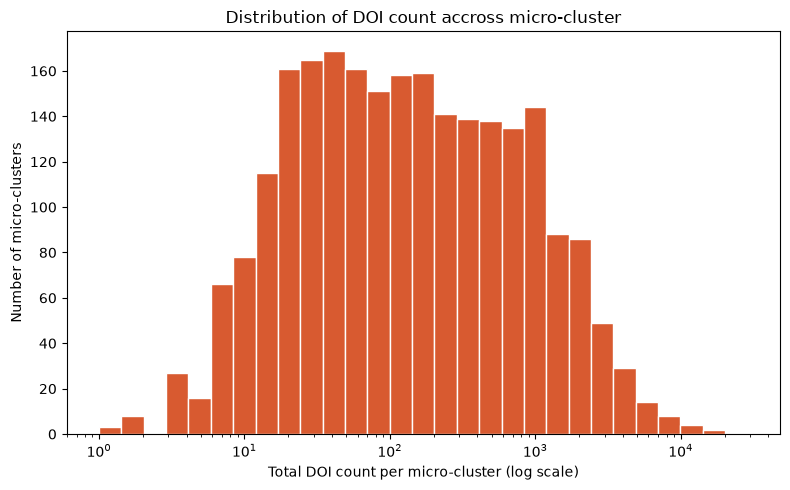

n               = 2415
mean            = 534.0
median          = 121.0
std             = 1289.9
min             = 1
max             = 28804
quantile 1      = 32.0
Quantile 3      = 518.5
IQR             = 486.5
upper whisker   = 1248.2
lower whisker   = 1.0
n outliers      = 269 (11.1%)


C:\Users\Kayle\AppData\Local\Temp\ipykernel_36544\1444307907.py:55: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(micro_cluster_sizes.values, vert=True)


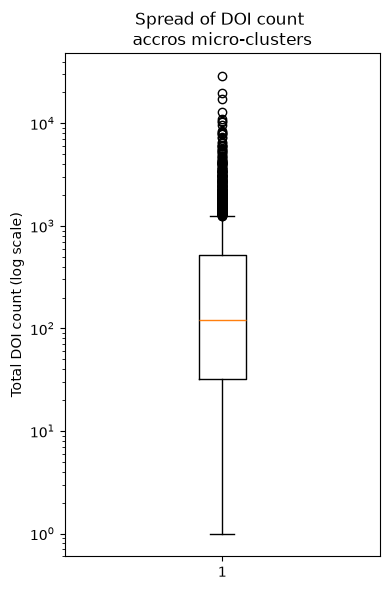

In [ ]:
ROOT_FIGURES_DIR = Path('../images_micro_micro/')

def plot_micro_cluster_doi_count(
    community_summary_df,
    evaluation,
    save_enabled: bool = False,
):
    """
    COPY PASTAAAADDDD (LOVE ME A PASTA) FROM 10_MICRO_FOCUSED_VISUALIZATIONS.IPYNB
    Distribution of DOI count of micro clusters of the reference set that were correctly predicted
    """
    micro_clusters_with_correct_prediction = set(evaluation[evaluation['correct'] == True]['micro_cluster_id'].values)

    micro_cluster_sizes = (
        community_summary_df[community_summary_df['micro_cluster_id'].isin(micro_clusters_with_correct_prediction)]
        .groupby('micro_cluster_id')['doi_count']
        .sum()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    bins = np.logspace(np.log10(micro_cluster_sizes.min()),
                        np.log10(micro_cluster_sizes.max()), 30)
    ax.hist(micro_cluster_sizes, bins=bins, color='#D85A30', edgecolor='white')
    ax.set_xscale('log')
    ax.set_xlabel('Total DOI count per micro-cluster (log scale)')
    ax.set_ylabel('Number of micro-clusters')
    ax.set_title('Distribution of DOI count accross micro-cluster')
    plt.tight_layout()
    # self._save(f'Distribution_of_DOI_count_accross_micro_cluster', save_enabled)
    plt.savefig(ROOT_FIGURES_DIR / 'Distribution_of_DOI_count_accross_micro_cluster_(succes_only)')
    plt.show()

    desc = micro_cluster_sizes.describe()
    q1, q3 = micro_cluster_sizes.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_whisker = q3 + 1.5 * iqr
    lower_whisker = max(q1 - 1.5 * iqr, micro_cluster_sizes.min())
    outliers = micro_cluster_sizes[micro_cluster_sizes > upper_whisker]

    print(f"n               = {len(micro_cluster_sizes)}")
    print(f"mean            = {desc['mean']:.1f}")
    print(f"median          = {desc['50%']:.1f}")
    print(f"std             = {desc['std']:.1f}")
    print(f"min             = {desc['min']:.0f}")
    print(f"max             = {desc['max']:.0f}")
    print(f"quantile 1      = {q1:.1f}")
    print(f"Quantile 3      = {q3:.1f}")
    print(f"IQR             = {iqr:.1f}")
    print(f"upper whisker   = {upper_whisker:.1f}")
    print(f"lower whisker   = {lower_whisker:.1f}")
    print(f"n outliers      = {len(outliers)} ({len(outliers)/len(micro_cluster_sizes):.1%})")

    fig, ax = plt.subplots(figsize=(4, 6))
    ax.boxplot(micro_cluster_sizes.values, vert=True)
    ax.set_yscale('log')
    ax.set_ylabel('Total DOI count (log scale)')
    ax.set_title('Spread of DOI count \naccros micro-clusters')
    plt.tight_layout()
    plt.savefig(ROOT_FIGURES_DIR / 'Spread_of_Doi_count_accross_micro_clusters_(succes_only)')
    plt.show()

plot_micro_cluster_doi_count(community_summary_df, evaluation)

In [ ]:
# four graphs discussed in the paper
top_4_rna_seq_analysis = { 313, 312, 311, 315 }

community_summary_df[community_summary_df['community'].isin(top_4_rna_seq_analysis)]

,community,community_size,doi_count,software_freq,doi_freq,macro_cluster_freq,meso_cluster_freq,micro_cluster_freq,main_field_freq,micro_cluster_id,community_index,modularity,nmi_mean,nmi_std,nmi_min,nmi_max,cmi_mean,cmi_std,cmi_min,cmi_max
311,311,3411,5649,"{'NanoSim': 19, 'BioProject': 6, 'UCSC liftOve...","{'10.1038/s41598-019-40739-8': 13, '10.1038/s4...",{4: 5649},{119: 5649},{15: 5649},"{'Life and earth sciences': 5649, 'Biomedical ...",15,0,0.290162,0.782019,0.016106,0.761342,0.800631,0.777765,0.016423,0.756661,0.796714
312,312,2232,7035,"{'MetaPGN': 1, 'ARACHNE': 13, 'Annotation usin...","{'10.1186/s13059-020-02090-4': 16, '10.1038/sd...",{4: 7035},{119: 7035},{15: 7035},"{'Life and earth sciences': 7035, 'Biomedical ...",15,1,0.290162,0.782019,0.016106,0.761342,0.800631,0.777765,0.016423,0.756661,0.796714
313,313,2157,7673,"{'Frame Finder': 4, 'CLC Genome Workbench': 2,...","{'10.1002/ece3.5606': 17, '10.1016/j.cub.2019....",{4: 7673},{119: 7673},{15: 7673},"{'Life and earth sciences': 7673, 'Biomedical ...",15,2,0.290162,0.782019,0.016106,0.761342,0.800631,0.777765,0.016423,0.756661,0.796714
315,315,1504,4501,"{'chainNet': 5, 'windowBed': 1, 'VicPac3': 1, ...","{'10.1093/gigascience/giaa092': 25, '10.1093/g...",{4: 4501},{119: 4501},{15: 4501},"{'Life and earth sciences': 4501, 'Biomedical ...",15,4,0.290162,0.782019,0.016106,0.761342,0.800631,0.777765,0.016423,0.756661,0.796714
